In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [5]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

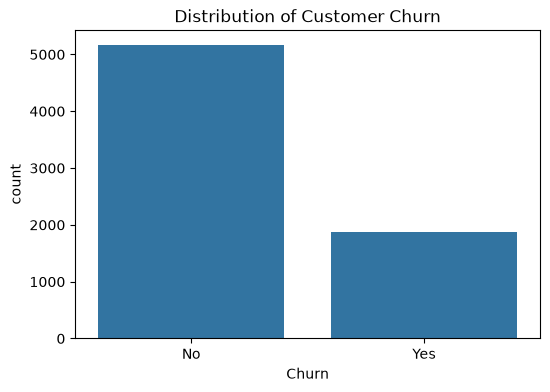

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")
plt.title("Distribution of Customer Churn")
plt.show()

### Observation

- Majority of customers did not churn.
- The dataset is moderately imbalanced.
- This should be considered during model evaluation.
- Accuracy alone may not be a sufficient evaluation metric; precision, recall, and F1-score should also be considered during model evaluation.

In [7]:
numerical_features = df.select_dtypes(include=["number"]).columns.tolist()
categorical_features = df.select_dtypes(include=["str"]).columns.tolist()

In [8]:
print(df.dtypes.unique())

[<StringDtype(na_value=nan)> dtype('int64') dtype('float64')]


In [9]:
numerical_features

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [10]:
categorical_features

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [11]:
# Remove identifier column
categorical_features.remove("customerID")

# Treat binary variable as categorical
numerical_features.remove("SeniorCitizen")
categorical_features.append("SeniorCitizen")

# Numerical Feature Analysis

This section explores the distribution and characteristics of numerical features in the dataset.

In [12]:
numerical_features

['tenure', 'MonthlyCharges', 'TotalCharges']

In [13]:
df['tenure'].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

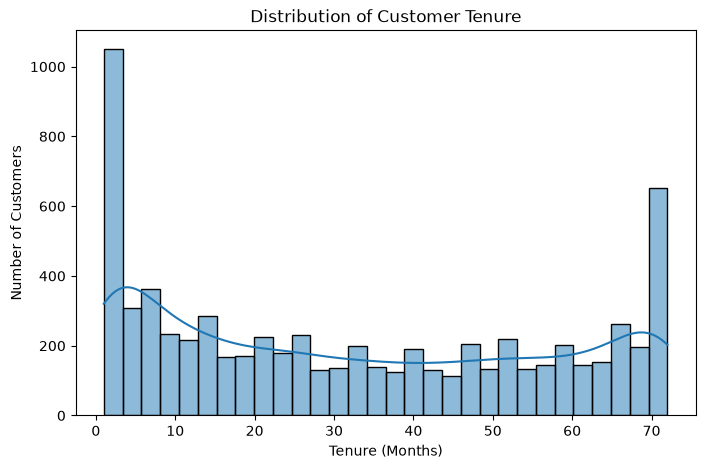

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="tenure", bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

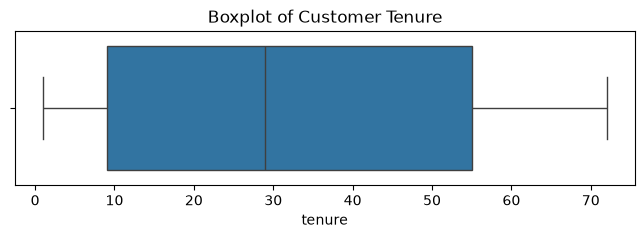

In [15]:
plt.figure(figsize=(8,2))

sns.boxplot(data=df,x="tenure")
plt.title("Boxplot of Customer Tenure")
plt.show()

### Observations

- Customer tenure ranges from 1 to 72 months.
- Most customers have relatively low tenure.
- Another concentration exists near the maximum tenure.
- The distribution is not perfectly symmetric.

In [16]:
df['MonthlyCharges'].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

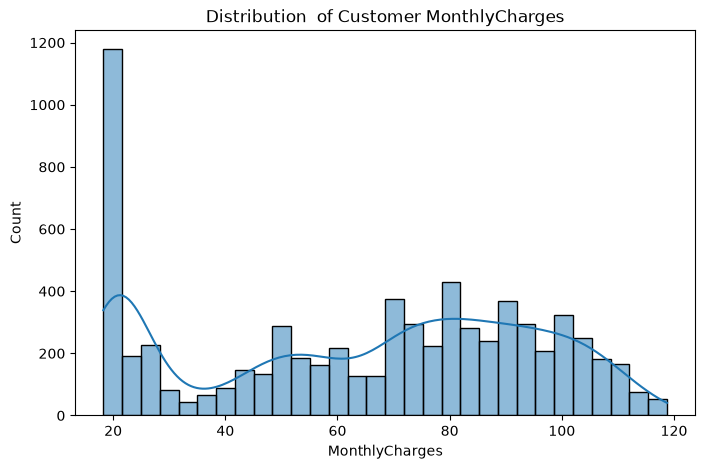

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="MonthlyCharges", bins=30, kde=True)
plt.title("Distribution  of Customer MonthlyCharges")

plt.show()

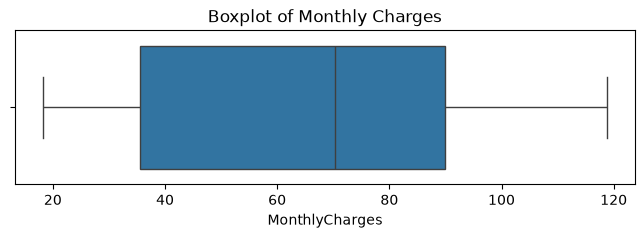

In [18]:
plt.figure(figsize=(8,2))

sns.boxplot(
    data=df,
    x="MonthlyCharges"
)

plt.title("Boxplot of Monthly Charges")
plt.show()

### Observations

- Monthly charges vary across a wide range.
- The distribution is slightly skewed.
- The boxplot does not indicate a large number of extreme outliers.
- Most customers fall within the central range of monthly charges.

In [19]:
df["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

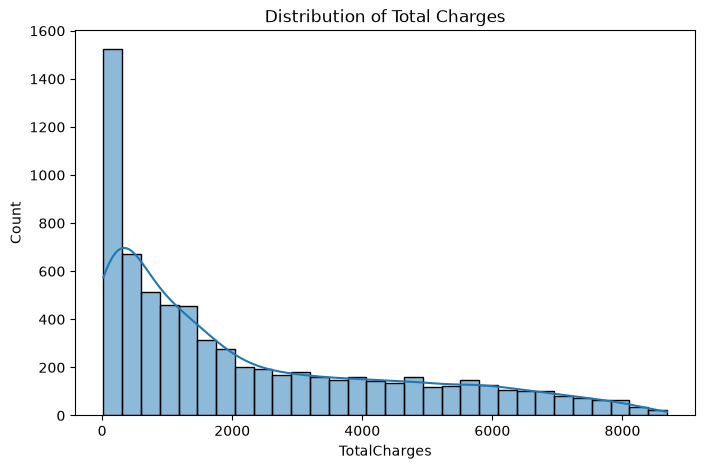

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df, x="TotalCharges", bins=30,
    kde=True
)

plt.title("Distribution of Total Charges")
plt.show()

### Observations

- Total charges exhibit a wide spread among customers.
- The distribution is positively skewed.
- Higher total charges are observed for a smaller number of customers.
- A few high-value observations appear in the boxplot.

# 3. Categorical Feature Analysis

In this section, we examine the distribution of important categorical features to understand customer demographics, service usage, and subscription characteristics.

In [21]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df['gender'].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [24]:
(df["gender"].value_counts(normalize=True) * 100).round(2)

gender
Male      50.47
Female    49.53
Name: proportion, dtype: float64

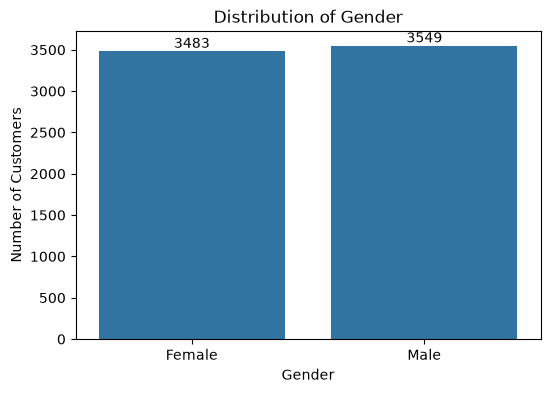

In [25]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="gender")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Male and female customers are almost equally represented.
- No significant gender imbalance is observed.

In [26]:
df['SeniorCitizen_Label'] = df['SeniorCitizen'].map( {0: 'No', 1: 'Yes'} )

In [27]:
df['SeniorCitizen_Label'].value_counts(normalize=True) * 100

SeniorCitizen_Label
No     83.759954
Yes    16.240046
Name: proportion, dtype: float64

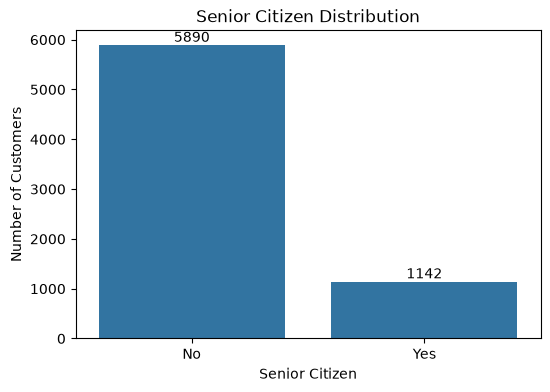

In [28]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="SeniorCitizen_Label")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Senior Citizen Distribution")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Most customers are not senior citizens.
- Senior citizens represent a smaller proportion of the customer base.

In [29]:
df['Partner'].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

In [30]:
df['Partner'].value_counts(normalize=True) * 100

Partner
No     51.749147
Yes    48.250853
Name: proportion, dtype: float64

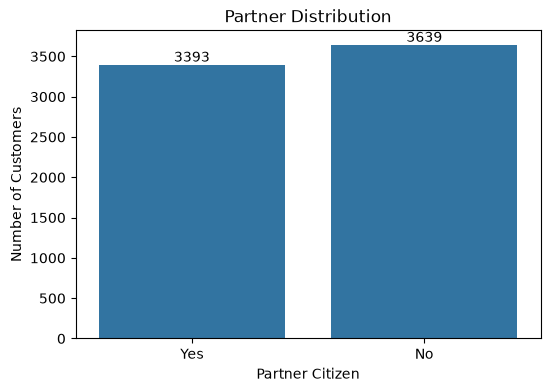

In [31]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Partner")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Partner Distribution")
plt.xlabel("Partner Citizen")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Partner - yes or No are almost equally represented.
- No significant Partner imbalance is observed.

In [32]:
df['Dependents'].value_counts(normalize=True) * 100

Dependents
No     70.150739
Yes    29.849261
Name: proportion, dtype: float64

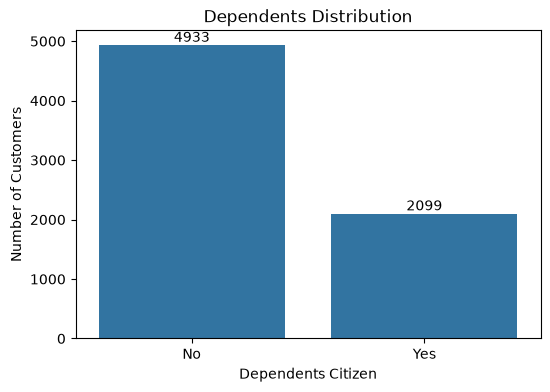

In [33]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Dependents")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Dependents Distribution")
plt.xlabel("Dependents Citizen")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Most customers are in not Dependent Category.

In [34]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [35]:
(df["InternetService"].value_counts(normalize=True) * 100)

InternetService
Fiber optic    44.027304
DSL            34.357224
No             21.615472
Name: proportion, dtype: float64

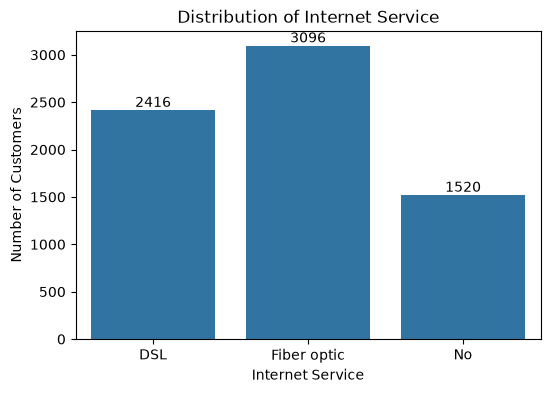

In [36]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="InternetService")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- DSL and Fiber optics are main internet services
- a smaller group of customers has no internet services

In [37]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [38]:
df["Contract"].value_counts(normalize=True) * 100

Contract
Month-to-month    55.105233
Two year          23.961889
One year          20.932878
Name: proportion, dtype: float64

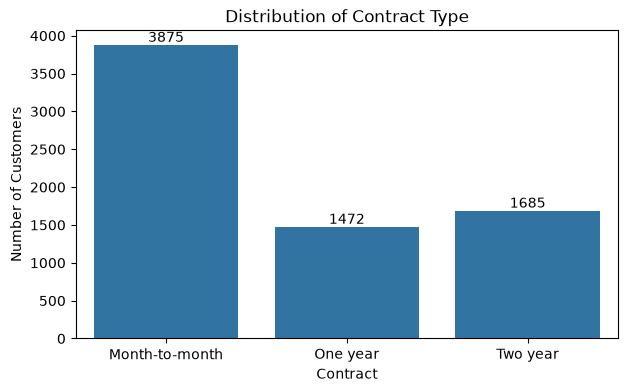

In [39]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=df,
    x="Contract"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Most of the customers have Month to Month contract 
- Then some has One year and some group has 2 year Contract

In [40]:
df['PaperlessBilling'].value_counts(normalize=True) * 100

PaperlessBilling
Yes    59.2719
No     40.7281
Name: proportion, dtype: float64

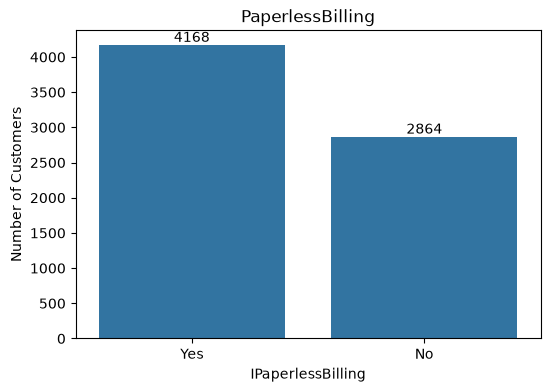

In [41]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="PaperlessBilling")

for container in ax.containers:
    ax.bar_label(container)

plt.title("PaperlessBilling")
plt.xlabel("IPaperlessBilling")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Approximately **59.27%** of customers use paperless billing, while **40.72%** do not.
- Paperless billing is more commonly used among customers in the dataset.
- The distribution indicates a moderate preference for paperless billing over traditional billing methods.

In [46]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']